<a href="https://colab.research.google.com/github/maslim734/for-you/blob/main/jurti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# ============================================================
# IMPORT LIBRARY
# Penelitian:
# Improvisasi Akurasi Algoritma Machine Learning
# dengan Metode GridSearchCV pada Kasus Klasifikasi
# Penyakit Daun Mangga
# ============================================================

import os
import cv2
import joblib
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

print("="*60)
print("SEMUA LIBRARY BERHASIL DIIMPORT")
print("="*60)

SEMUA LIBRARY BERHASIL DIIMPORT


In [20]:
from google.colab import drive
drive.mount('/content/drive')
dataset_path = "/content/drive/MyDrive/pengolahan_cita_digital/archive/MangoLeafBD Dataset/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
# ============================================================
# LOKASI DATASET
# ============================================================



print(dataset_path)

/content/drive/MyDrive/pengolahan_cita_digital/archive/MangoLeafBD Dataset/


In [22]:
# ============================================================
# MEMBACA DATASET HASIL EKSTRAKSI GLCM
# ============================================================

df = pd.read_csv(
    os.path.join(
        dataset_path,
        "glcm_features_v3.csv"
    )
)

print("="*60)
print("Jumlah Data :",len(df))
print("Jumlah Fitur :",len(df.columns)-1)
print("="*60)

df.head()

Jumlah Data : 4000
Jumlah Fitur : 79


,Contrast_D1_A0,Contrast_D1_A45,Contrast_D1_A90,Contrast_D1_A135,Contrast_D2_A0,Contrast_D2_A45,Contrast_D2_A90,Contrast_D2_A135,Contrast_D3_A0,Contrast_D3_A45,...,ASM_D3_A90,ASM_D3_A135,Mean,Std,Variance,Median,Skewness,Kurtosis,Entropy,Label
0,14.208260,18.680810,6.973735,19.583442,46.318131,18.680810,20.594253,19.583442,91.156614,58.699761,...,0.002189,0.002126,170.512915,31.802771,1011.416247,180.0,-1.094114,0.430305,6.627675,Anthracnose
1,14.181514,19.562629,7.050529,18.828289,46.222772,19.562629,20.477035,18.828289,90.823449,60.942415,...,0.001829,0.001823,171.671118,31.629597,1000.431417,179.0,-1.149195,0.656935,6.648672,Anthracnose
2,17.887792,26.920449,9.685999,23.105009,59.403616,26.920449,29.633748,23.105009,117.125566,84.800929,...,0.001052,0.001029,161.996991,34.936481,1220.557728,170.0,-0.762538,-0.104302,6.951820,Anthracnose
3,17.489510,25.772628,9.493013,22.947234,57.295105,25.772628,28.977296,22.947234,112.533351,80.942497,...,0.000951,0.000888,159.938835,35.024471,1226.713594,165.0,-0.568663,-0.210059,7.025922,Anthracnose
4,28.742353,39.923224,12.228760,34.879426,96.278998,39.923224,37.770713,34.879426,191.063672,127.449679,...,0.001117,0.000977,171.265226,40.975705,1679.008418,182.0,-0.945246,-0.092431,6.979934,Anthracnose


In [23]:
# ============================================================
# MEMISAHKAN FITUR DAN LABEL
# ============================================================

X = df.drop(
    "Label",
    axis=1
)

y = df["Label"]

print(X.shape)
print(y.shape)

(4000, 79)
(4000,)


In [24]:
# ============================================================
# ENCODING LABEL
# ============================================================

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Jumlah Kelas :",len(np.unique(y)))
print("Nama Kelas :")

for i,label in enumerate(encoder.classes_):
    print(i,"=",label)

Jumlah Kelas : 8
Nama Kelas :
0 = Anthracnose
1 = Bacterial Canker
2 = Cutting Weevil
3 = Die Back
4 = Gall Midge
5 = Healthy
6 = Powdery Mildew
7 = Sooty Mould


In [25]:
# ============================================================
# PEMBAGIAN DATA
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [26]:
print("="*60)

print("DATA TRAIN")

print(X_train.shape)

print(y_train.shape)

print("="*60)

print("DATA TEST")

print(X_test.shape)

print(y_test.shape)

print("="*60)

DATA TRAIN
(3200, 79)
(3200,)
DATA TEST
(800, 79)
(800,)


In [27]:
# ============================================================
# CEK DATA
# ============================================================

display(df.head())

display(df.describe())

display(df.info())

,Contrast_D1_A0,Contrast_D1_A45,Contrast_D1_A90,Contrast_D1_A135,Contrast_D2_A0,Contrast_D2_A45,Contrast_D2_A90,Contrast_D2_A135,Contrast_D3_A0,Contrast_D3_A45,...,ASM_D3_A90,ASM_D3_A135,Mean,Std,Variance,Median,Skewness,Kurtosis,Entropy,Label
0,14.208260,18.680810,6.973735,19.583442,46.318131,18.680810,20.594253,19.583442,91.156614,58.699761,...,0.002189,0.002126,170.512915,31.802771,1011.416247,180.0,-1.094114,0.430305,6.627675,Anthracnose
1,14.181514,19.562629,7.050529,18.828289,46.222772,19.562629,20.477035,18.828289,90.823449,60.942415,...,0.001829,0.001823,171.671118,31.629597,1000.431417,179.0,-1.149195,0.656935,6.648672,Anthracnose
2,17.887792,26.920449,9.685999,23.105009,59.403616,26.920449,29.633748,23.105009,117.125566,84.800929,...,0.001052,0.001029,161.996991,34.936481,1220.557728,170.0,-0.762538,-0.104302,6.951820,Anthracnose
3,17.489510,25.772628,9.493013,22.947234,57.295105,25.772628,28.977296,22.947234,112.533351,80.942497,...,0.000951,0.000888,159.938835,35.024471,1226.713594,165.0,-0.568663,-0.210059,7.025922,Anthracnose
4,28.742353,39.923224,12.228760,34.879426,96.278998,39.923224,37.770713,34.879426,191.063672,127.449679,...,0.001117,0.000977,171.265226,40.975705,1679.008418,182.0,-0.945246,-0.092431,6.979934,Anthracnose


,Contrast_D1_A0,Contrast_D1_A45,Contrast_D1_A90,Contrast_D1_A135,Contrast_D2_A0,Contrast_D2_A45,Contrast_D2_A90,Contrast_D2_A135,Contrast_D3_A0,Contrast_D3_A45,...,ASM_D3_A45,ASM_D3_A90,ASM_D3_A135,Mean,Std,Variance,Median,Skewness,Kurtosis,Entropy
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,42.786851,80.435522,44.182264,77.710941,136.002268,80.435522,140.925111,77.710941,254.256581,243.333443,...,0.002693,0.002715,0.002731,180.427288,48.706318,2516.171129,198.678750,-1.414152,1.635332,6.650530
std,26.934474,46.089767,26.131232,46.844337,85.981529,46.089767,84.108516,46.844337,159.260092,138.174166,...,0.002271,0.002369,0.002303,12.880676,11.995902,1192.296022,18.612406,0.702872,2.764267,0.438620
min,3.935939,7.842265,3.278808,8.037564,11.571087,7.842265,9.293798,8.037564,22.153745,23.104699,...,0.000099,0.000100,0.000104,109.828882,16.055995,257.794978,99.000000,-3.998889,-1.813110,5.287971
25%,21.577314,44.610554,22.808446,43.468062,69.293909,44.610554,72.629414,43.468062,131.325549,137.637956,...,0.001380,0.001393,0.001405,173.956538,39.167861,1534.121300,190.000000,-1.940035,-0.563088,6.342931
50%,36.643077,70.028685,41.102869,67.038076,116.378258,70.028685,129.789404,67.038076,216.961185,212.933031,...,0.002325,0.002246,0.002315,181.399524,48.107469,2314.328696,199.000000,-1.447910,0.895279,6.608256
75%,59.007712,106.464523,60.057961,101.299347,187.777530,106.464523,191.999216,101.299347,347.522241,316.615859,...,0.003317,0.003277,0.003308,189.009163,58.467690,3418.470879,211.000000,-0.888574,3.307206,6.980816
max,172.241392,289.395584,155.752322,270.546582,541.507119,289.395584,487.097752,270.546582,1015.351891,891.060162,...,0.038245,0.037172,0.038801,213.367128,82.453049,6798.505224,239.000000,1.042485,21.567871,7.653512


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 80 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Contrast_D1_A0         4000 non-null   float64
 1   Contrast_D1_A45        4000 non-null   float64
 2   Contrast_D1_A90        4000 non-null   float64
 3   Contrast_D1_A135       4000 non-null   float64
 4   Contrast_D2_A0         4000 non-null   float64
 5   Contrast_D2_A45        4000 non-null   float64
 6   Contrast_D2_A90        4000 non-null   float64
 7   Contrast_D2_A135       4000 non-null   float64
 8   Contrast_D3_A0         4000 non-null   float64
 9   Contrast_D3_A45        4000 non-null   float64
 10  Contrast_D3_A90        4000 non-null   float64
 11  Contrast_D3_A135       4000 non-null   float64
 12  Dissimilarity_D1_A0    4000 non-null   float64
 13  Dissimilarity_D1_A45   4000 non-null   float64
 14  Dissimilarity_D1_A90   4000 non-null   float64
 15  Diss

None

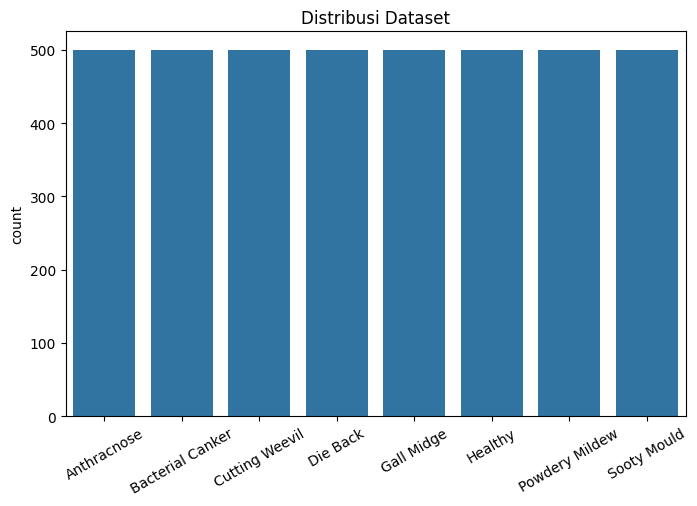

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=encoder.inverse_transform(y)
)

plt.title("Distribusi Dataset")

plt.xticks(rotation=30)

plt.show()

In [29]:
# ============================================================
# FUNGSI EVALUASI MODEL
# ============================================================

hasil = []

def evaluate_model(model, model_name):
    """
    Melatih model, melakukan prediksi,
    menghitung metrik evaluasi,
    dan menyimpan hasil ke tabel.
    """

    print("="*70)
    print(f"MODEL : {model_name}")
    print("="*70)

    # Training
    model.fit(X_train, y_train)

    # Prediksi
    y_pred = model.predict(X_test)

    # Metrik Evaluasi
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    # Simpan hasil
    hasil.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=encoder.classes_,
        yticklabels=encoder.classes_
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    return model

MODEL : KNN Default
Accuracy : 0.8588
Precision: 0.8661
Recall   : 0.8588
F1 Score : 0.8596

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.75      0.82       100
           1       1.00      0.91      0.95       100
           2       1.00      1.00      1.00       100
           3       0.91      0.96      0.93       100
           4       0.68      0.86      0.76       100
           5       0.83      0.74      0.78       100
           6       0.83      0.87      0.85       100
           7       0.79      0.78      0.78       100

    accuracy                           0.86       800
   macro avg       0.87      0.86      0.86       800
weighted avg       0.87      0.86      0.86       800



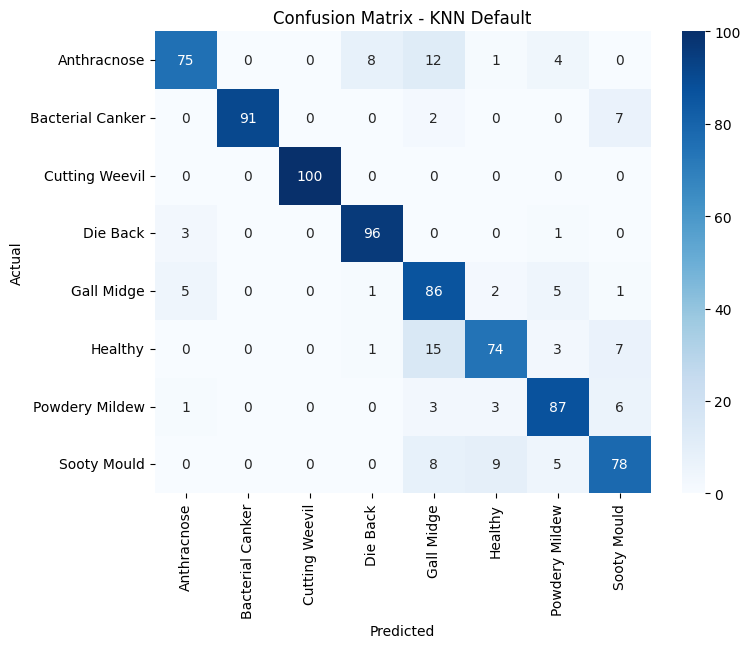

In [30]:
# ============================================================
# KNN DEFAULT
# ============================================================

knn_default = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

best_knn_default = evaluate_model(
    knn_default,
    "KNN Default"
)

In [31]:
# ============================================================
# GRIDSEARCHCV KNN
# ============================================================

pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

param_grid_knn = {

    "model__n_neighbors":[3,5,7,9],

    "model__weights":[
        "uniform",
        "distance"
    ]

}

grid_knn = GridSearchCV(

    estimator=pipeline_knn,

    param_grid=param_grid_knn,

    scoring="accuracy",

    cv=5,

    n_jobs=-1,

    verbose=2

)

In [32]:
grid_knn.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'model__n_neighbors': [3, 5, 7, 9],
                         'model__weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=2)

In [33]:
print("="*60)
print("BEST PARAMETER KNN")
print("="*60)

print(grid_knn.best_params_)

print()

print("BEST CROSS VALIDATION SCORE")

print(grid_knn.best_score_)

BEST PARAMETER KNN
{'model__n_neighbors': 3, 'model__weights': 'distance'}

BEST CROSS VALIDATION SCORE
0.8378125000000001


MODEL : KNN + GridSearchCV
Accuracy : 0.8588
Precision: 0.8673
Recall   : 0.8588
F1 Score : 0.8594

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.73      0.81       100
           1       1.00      0.91      0.95       100
           2       1.00      1.00      1.00       100
           3       0.91      0.96      0.94       100
           4       0.69      0.84      0.76       100
           5       0.85      0.71      0.77       100
           6       0.82      0.89      0.86       100
           7       0.75      0.83      0.79       100

    accuracy                           0.86       800
   macro avg       0.87      0.86      0.86       800
weighted avg       0.87      0.86      0.86       800



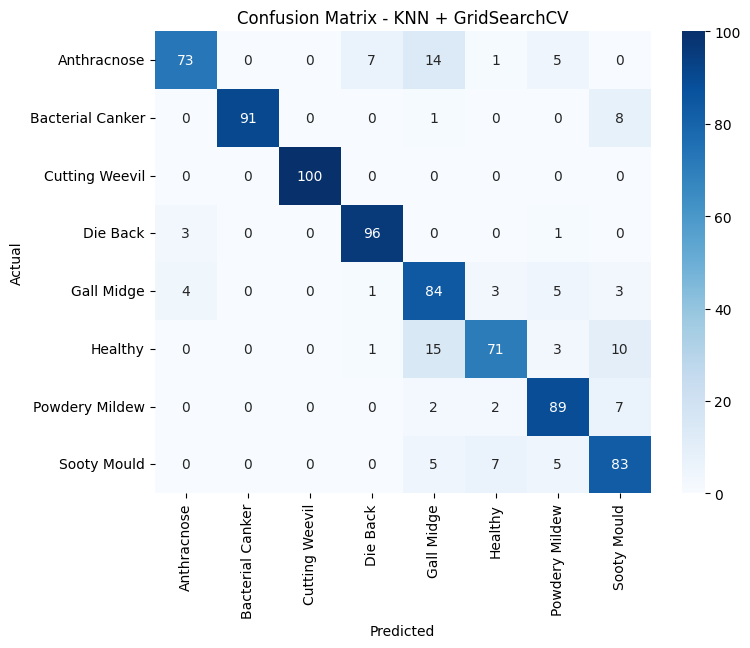

In [34]:
best_knn = evaluate_model(

    grid_knn.best_estimator_,

    "KNN + GridSearchCV"

)

In [35]:
# ============================================================
# SIMPAN MODEL KNN GRIDSEARCHCV
# ============================================================

joblib.dump(

    grid_knn.best_estimator_,

    "knn_gridsearch.pkl"

)

print("="*60)
print("Model KNN GridSearchCV berhasil disimpan.")
print("="*60)

Model KNN GridSearchCV berhasil disimpan.


MODEL : SVM Default
Accuracy : 0.8912
Precision: 0.8937
Recall   : 0.8912
F1 Score : 0.8913

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.87      0.89       100
           1       1.00      0.97      0.98       100
           2       1.00      1.00      1.00       100
           3       0.93      0.93      0.93       100
           4       0.80      0.89      0.84       100
           5       0.76      0.84      0.80       100
           6       0.90      0.91      0.91       100
           7       0.84      0.72      0.77       100

    accuracy                           0.89       800
   macro avg       0.89      0.89      0.89       800
weighted avg       0.89      0.89      0.89       800



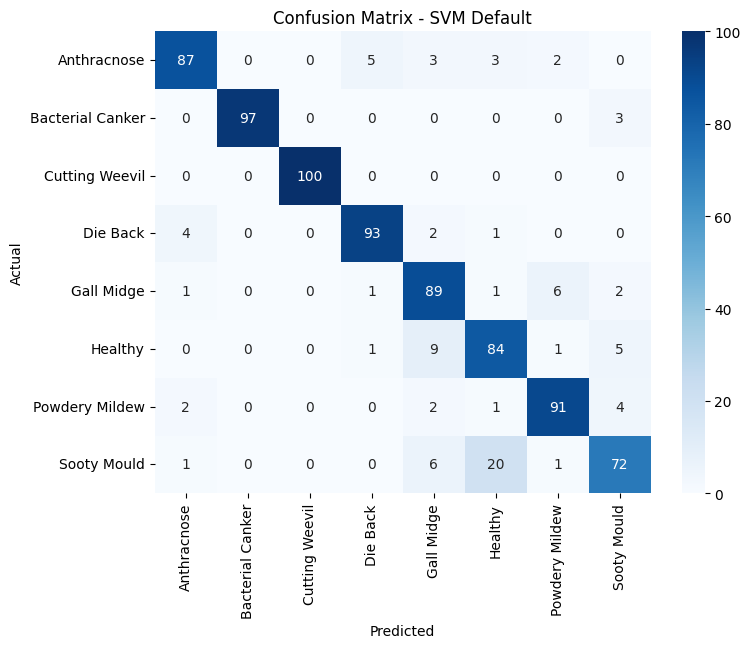

In [36]:
# ============================================================
# SUPPORT VECTOR MACHINE (DEFAULT)
# ============================================================

svm_default = Pipeline([

    ("scaler", StandardScaler()),

    ("model", SVC(
        random_state=42
    ))

])

best_svm_default = evaluate_model(

    svm_default,

    "SVM Default"

)

In [37]:
# ============================================================
# GRIDSEARCHCV SVM
# ============================================================

pipeline_svm = Pipeline([

    ("scaler", StandardScaler()),

    ("model", SVC())

])

param_grid_svm = {

    "model__C":[
        0.1,
        1,
        10
    ],

    "model__kernel":[
        "linear",
        "rbf"
    ],

    "model__gamma":[
        "scale"
    ]

}

grid_svm = GridSearchCV(

    estimator=pipeline_svm,

    param_grid=param_grid_svm,

    scoring="accuracy",

    cv=5,

    n_jobs=-1,

    verbose=2

)

In [38]:
grid_svm.fit(

    X_train,

    y_train

)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', SVC())]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10], 'model__gamma': ['scale'],
                         'model__kernel': ['linear', 'rbf']},
             scoring='accuracy', verbose=2)

In [39]:
print("="*60)

print("BEST PARAMETER SVM")

print("="*60)

print(grid_svm.best_params_)

print()

print("BEST CROSS VALIDATION SCORE")

print(grid_svm.best_score_)

BEST PARAMETER SVM
{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

BEST CROSS VALIDATION SCORE
0.9134375


MODEL : SVM + GridSearchCV
Accuracy : 0.9287
Precision: 0.9301
Recall   : 0.9287
F1 Score : 0.9287

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.86      0.91       100
           1       0.99      0.98      0.98       100
           2       1.00      1.00      1.00       100
           3       0.93      0.98      0.96       100
           4       0.87      0.90      0.89       100
           5       0.92      0.87      0.89       100
           6       0.91      0.94      0.93       100
           7       0.85      0.90      0.87       100

    accuracy                           0.93       800
   macro avg       0.93      0.93      0.93       800
weighted avg       0.93      0.93      0.93       800



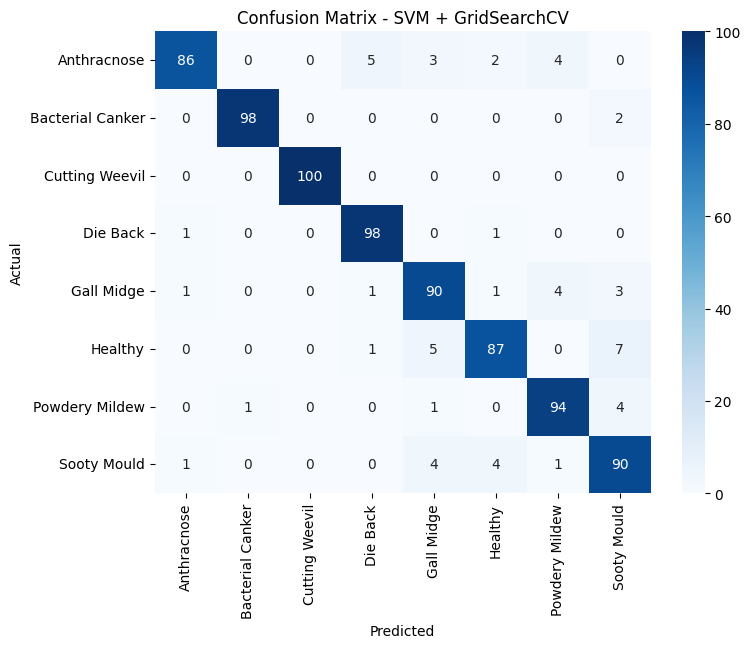

In [40]:
best_svm = evaluate_model(

    grid_svm.best_estimator_,

    "SVM + GridSearchCV"

)

In [41]:
joblib.dump(

    grid_svm.best_estimator_,

    "svm_gridsearch.pkl"

)

print("Model berhasil disimpan.")

Model berhasil disimpan.


MODEL : Decision Tree Default
Accuracy : 0.7738
Precision: 0.7760
Recall   : 0.7738
F1 Score : 0.7742

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.76      0.79       100
           1       0.97      0.92      0.94       100
           2       0.98      0.98      0.98       100
           3       0.83      0.89      0.86       100
           4       0.58      0.57      0.58       100
           5       0.61      0.65      0.63       100
           6       0.71      0.76      0.73       100
           7       0.70      0.66      0.68       100

    accuracy                           0.77       800
   macro avg       0.78      0.77      0.77       800
weighted avg       0.78      0.77      0.77       800



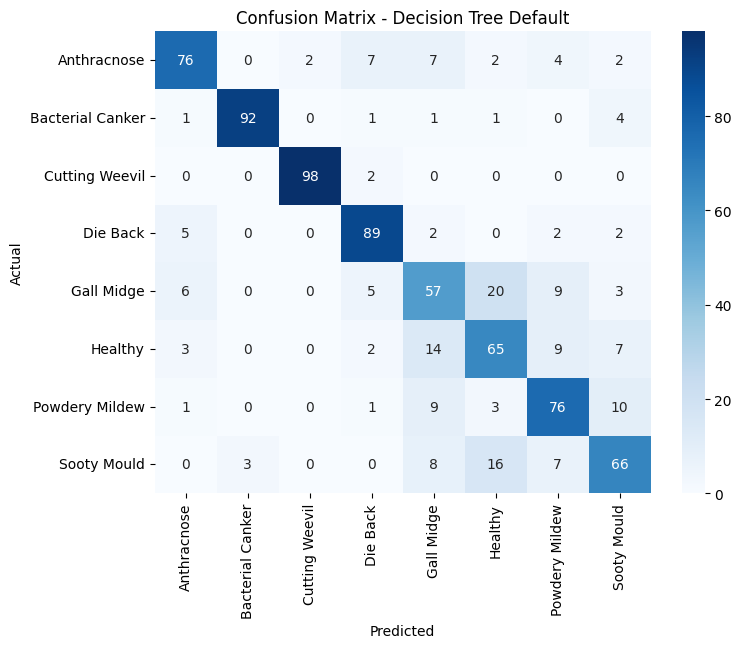

In [42]:
# ============================================================
# DECISION TREE (DEFAULT)
# ============================================================

dt_default = DecisionTreeClassifier(

    random_state=42

)

best_dt_default = evaluate_model(

    dt_default,

    "Decision Tree Default"

)

In [43]:
# ============================================================
# GRIDSEARCHCV DECISION TREE
# ============================================================

param_grid_dt = {

    "criterion":[

        "gini",

        "entropy"

    ],

    "max_depth":[

        10,

        20,

        None

    ],

    "min_samples_split":[

        2,

        5

    ],

    "min_samples_leaf":[

        1,

        2

    ]

}

grid_dt = GridSearchCV(

    estimator=DecisionTreeClassifier(

        random_state=42

    ),

    param_grid=param_grid_dt,

    cv=5,

    scoring="accuracy",

    n_jobs=-1,

    verbose=2

)

In [44]:
grid_dt.fit(

    X_train,

    y_train

)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5]},
             scoring='accuracy', verbose=2)

In [45]:
print("="*60)

print("BEST PARAMETER DECISION TREE")

print("="*60)

print(grid_dt.best_params_)

print()

print("BEST CROSS VALIDATION SCORE")

print(grid_dt.best_score_)

BEST PARAMETER DECISION TREE
{'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}

BEST CROSS VALIDATION SCORE
0.7631249999999999


MODEL : Decision Tree + GridSearchCV
Accuracy : 0.8250
Precision: 0.8264
Recall   : 0.8250
F1 Score : 0.8255

Classification Report
              precision    recall  f1-score   support

           0       0.78      0.83      0.80       100
           1       0.96      0.94      0.95       100
           2       0.98      0.96      0.97       100
           3       0.90      0.89      0.89       100
           4       0.68      0.69      0.68       100
           5       0.78      0.76      0.77       100
           6       0.76      0.75      0.75       100
           7       0.79      0.78      0.78       100

    accuracy                           0.82       800
   macro avg       0.83      0.82      0.83       800
weighted avg       0.83      0.82      0.83       800



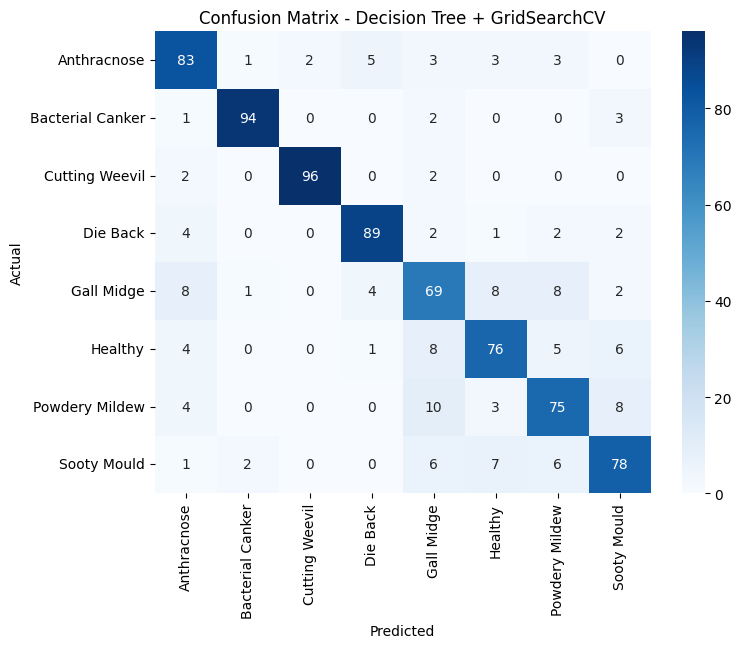

In [46]:
best_dt = evaluate_model(

    grid_dt.best_estimator_,

    "Decision Tree + GridSearchCV"

)

In [47]:
joblib.dump(

    grid_dt.best_estimator_,

    "decision_tree_gridsearch.pkl"

)

print("Model Decision Tree berhasil disimpan.")

Model Decision Tree berhasil disimpan.


MODEL : Random Forest Default
Accuracy : 0.8825
Precision: 0.8847
Recall   : 0.8825
F1 Score : 0.8825

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       100
           1       0.99      0.97      0.98       100
           2       1.00      1.00      1.00       100
           3       0.95      0.92      0.93       100
           4       0.77      0.82      0.80       100
           5       0.81      0.86      0.83       100
           6       0.82      0.89      0.85       100
           7       0.86      0.73      0.79       100

    accuracy                           0.88       800
   macro avg       0.88      0.88      0.88       800
weighted avg       0.88      0.88      0.88       800



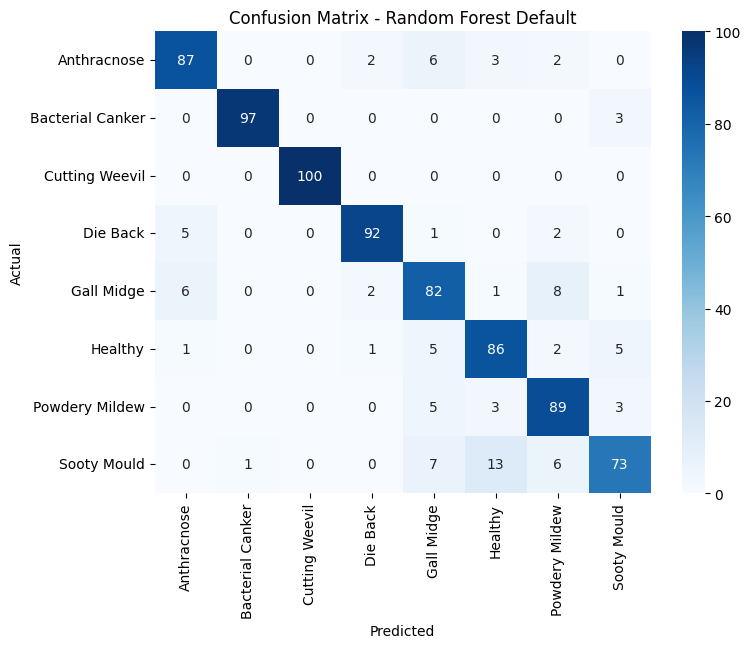

In [48]:
# ============================================================
# RANDOM FOREST (DEFAULT)
# ============================================================

rf_default = RandomForestClassifier(

    random_state=42

)

best_rf_default = evaluate_model(

    rf_default,

    "Random Forest Default"

)

In [49]:
# ============================================================
# GRIDSEARCHCV RANDOM FOREST
# ============================================================

param_grid_rf = {

    "n_estimators":[

        100,
        200

    ],

    "criterion":[

        "gini"

    ],

    "max_depth":[

        10,
        20,
        None

    ],

    "min_samples_split":[

        2,
        5

    ],

    "min_samples_leaf":[

        1,
        2

    ],

    "max_features":[

        "sqrt",
        "log2"

    ]

}

grid_rf = GridSearchCV(

    estimator=RandomForestClassifier(

        random_state=42

    ),

    param_grid=param_grid_rf,

    scoring="accuracy",

    cv=5,

    n_jobs=-1,

    verbose=2

)

In [50]:
grid_rf.fit(

    X_train,

    y_train

)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini'], 'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy', verbose=2)

In [51]:
print("="*70)

print("BEST PARAMETER RANDOM FOREST")

print("="*70)

print(grid_rf.best_params_)

print()

print("BEST CROSS VALIDATION SCORE")

print(grid_rf.best_score_)

BEST PARAMETER RANDOM FOREST
{'criterion': 'gini', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

BEST CROSS VALIDATION SCORE
0.8621875000000001


MODEL : Random Forest + GridSearchCV
Accuracy : 0.8862
Precision: 0.8879
Recall   : 0.8862
F1 Score : 0.8862

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       100
           1       0.99      0.98      0.98       100
           2       1.00      1.00      1.00       100
           3       0.94      0.93      0.93       100
           4       0.78      0.83      0.80       100
           5       0.81      0.87      0.84       100
           6       0.85      0.88      0.86       100
           7       0.85      0.74      0.79       100

    accuracy                           0.89       800
   macro avg       0.89      0.89      0.89       800
weighted avg       0.89      0.89      0.89       800



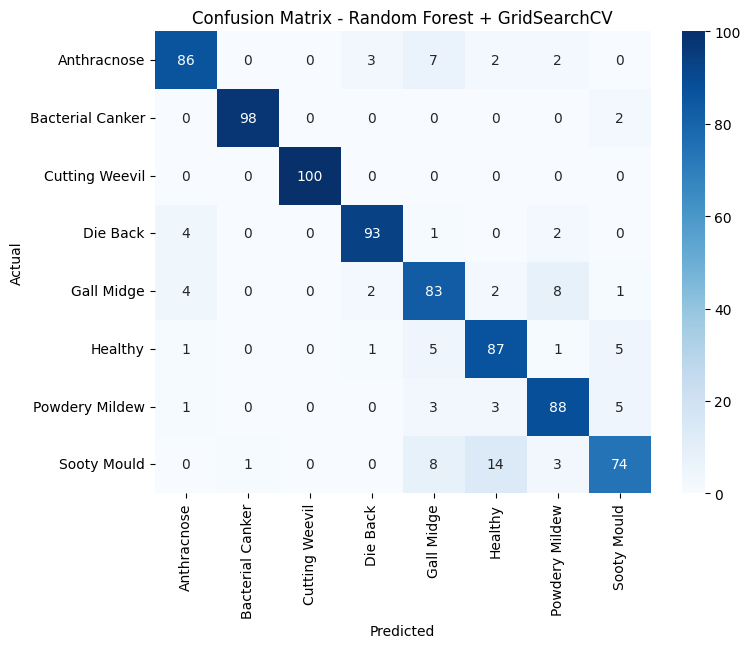

In [52]:
best_rf = evaluate_model(

    grid_rf.best_estimator_,

    "Random Forest + GridSearchCV"

)

In [53]:
importances = pd.DataFrame({

    "Feature":X.columns,

    "Importance":grid_rf.best_estimator_.feature_importances_

})

importances = importances.sort_values(

    by="Importance",

    ascending=False

)

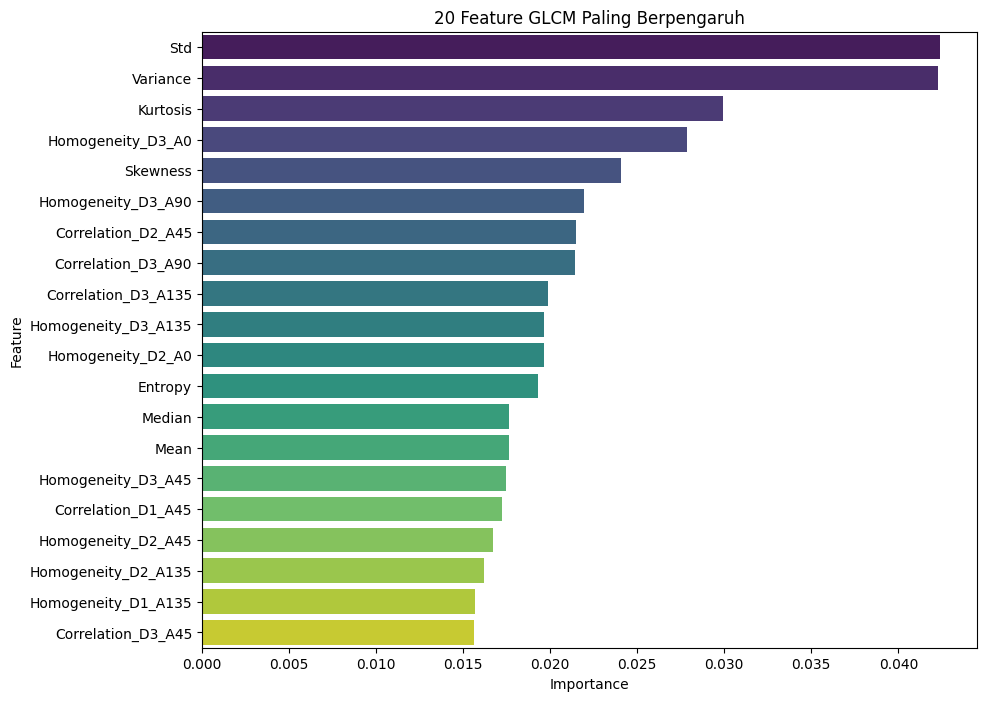

In [54]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importances.head(20),

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title(

    "20 Feature GLCM Paling Berpengaruh"

)

plt.show()

In [55]:
importances.to_excel(

    "feature_importance.xlsx",

    index=False

)

In [56]:
joblib.dump(

    grid_rf.best_estimator_,

    "random_forest_gridsearch.pkl"

)

print("Model berhasil disimpan.")

Model berhasil disimpan.


In [57]:
# ============================================================
# TABEL PERBANDINGAN HASIL
# ============================================================

hasil_df = pd.DataFrame(hasil)

hasil_df = hasil_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("="*70)
print("HASIL PENGUJIAN SELURUH MODEL")
print("="*70)

display(hasil_df)

HASIL PENGUJIAN SELURUH MODEL


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM + GridSearchCV,0.92875,0.930097,0.92875,0.928747
1,SVM Default,0.89125,0.893678,0.89125,0.891293
2,Random Forest + GridSearchCV,0.88625,0.887889,0.88625,0.886226
3,Random Forest Default,0.88250,0.884660,0.88250,0.882514
4,KNN Default,0.85875,0.866121,0.85875,0.859621
5,KNN + GridSearchCV,0.85875,0.867258,0.85875,0.859374
6,Decision Tree + GridSearchCV,0.82500,0.826363,0.82500,0.825516
7,Decision Tree Default,0.77375,0.775975,0.77375,0.774206


In [58]:
# ============================================================
# EXPORT HASIL KE EXCEL
# ============================================================

hasil_df.to_excel(

    "hasil_pengujian_gridsearchcv.xlsx",

    index=False

)

print("File Excel berhasil disimpan.")

File Excel berhasil disimpan.


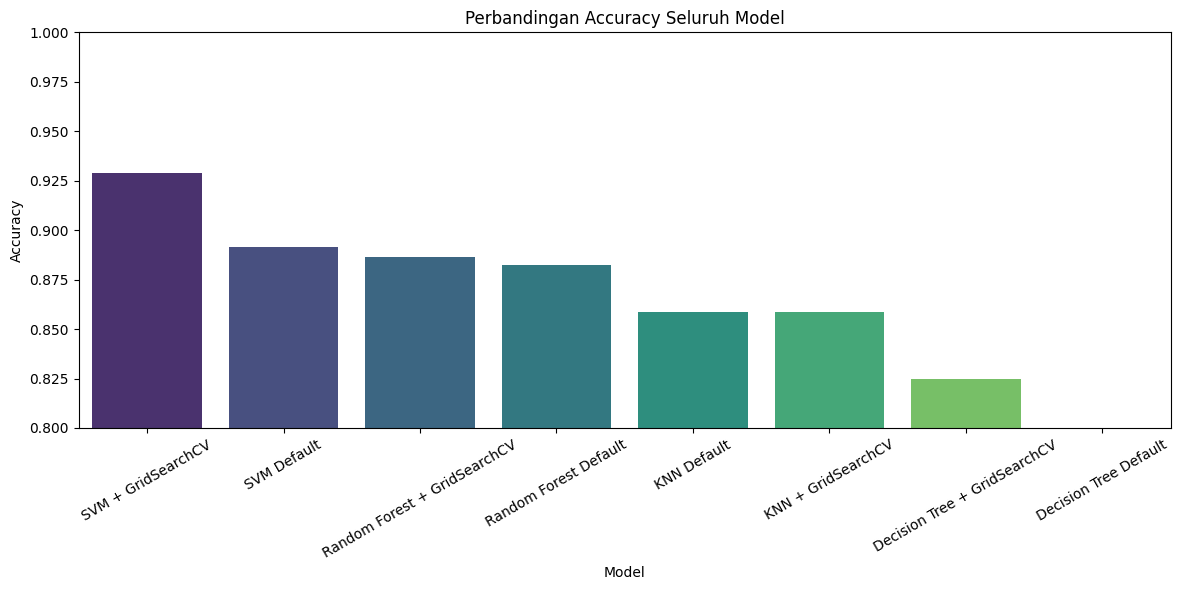

In [59]:
# ============================================================
# GRAFIK ACCURACY
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(

    data=hasil_df,

    x="Model",

    y="Accuracy",

    palette="viridis"

)

plt.xticks(rotation=30)

plt.ylim(0.80,1.00)

plt.title("Perbandingan Accuracy Seluruh Model")

plt.tight_layout()

plt.show()

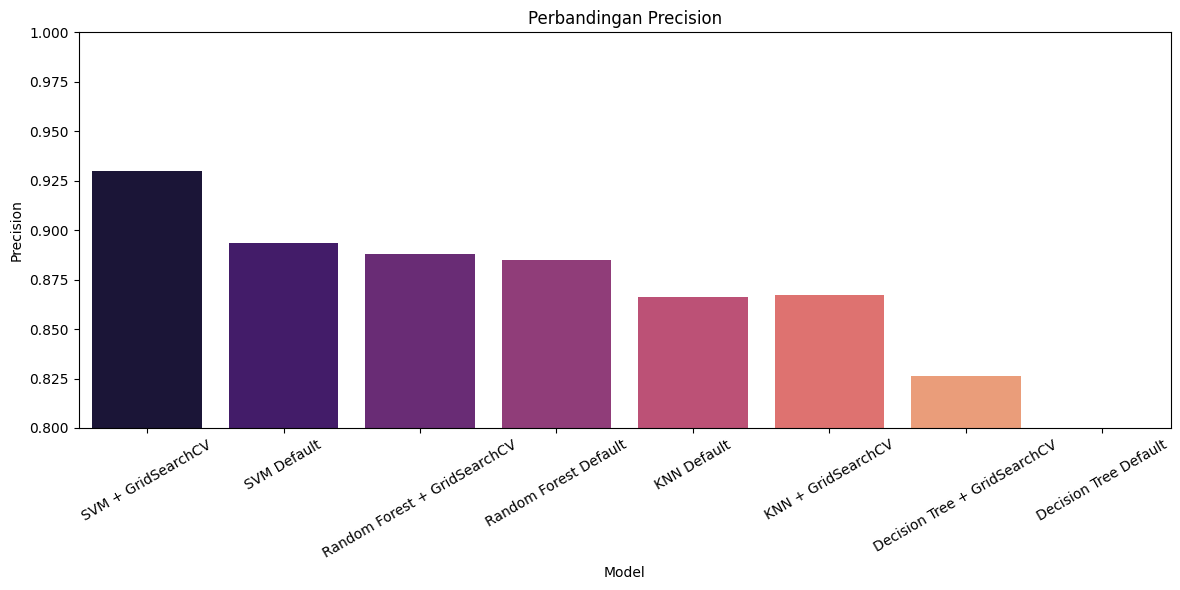

In [60]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=hasil_df,

    x="Model",

    y="Precision",

    palette="magma"

)

plt.xticks(rotation=30)

plt.ylim(0.80,1.00)

plt.title("Perbandingan Precision")

plt.tight_layout()

plt.show()

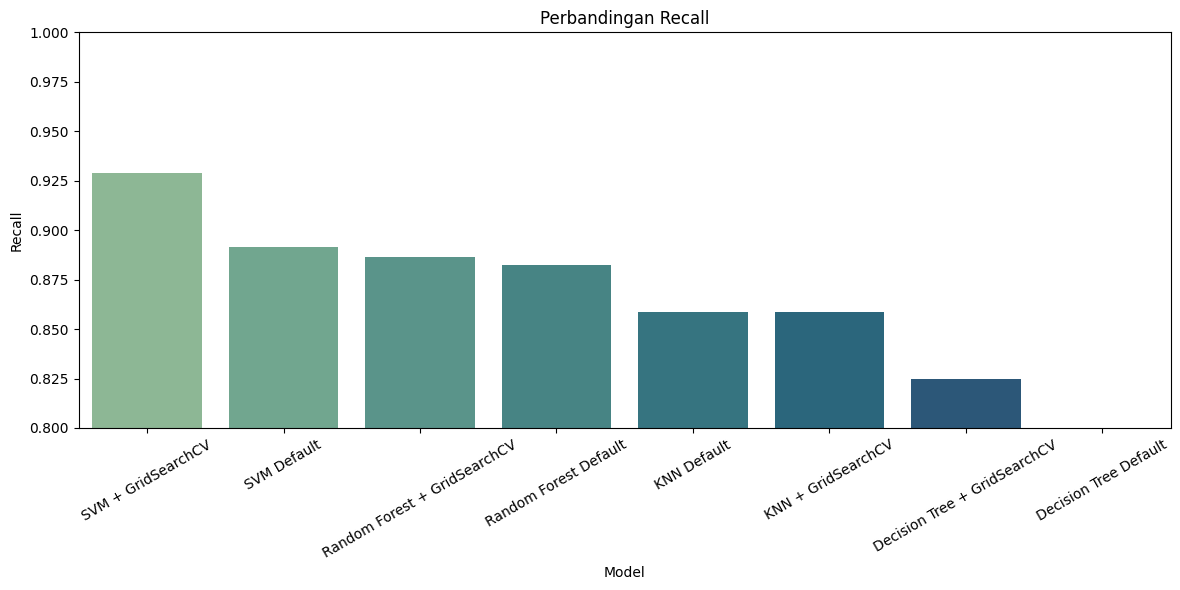

In [61]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=hasil_df,

    x="Model",

    y="Recall",

    palette="crest"

)

plt.xticks(rotation=30)

plt.ylim(0.80,1.00)

plt.title("Perbandingan Recall")

plt.tight_layout()

plt.show()

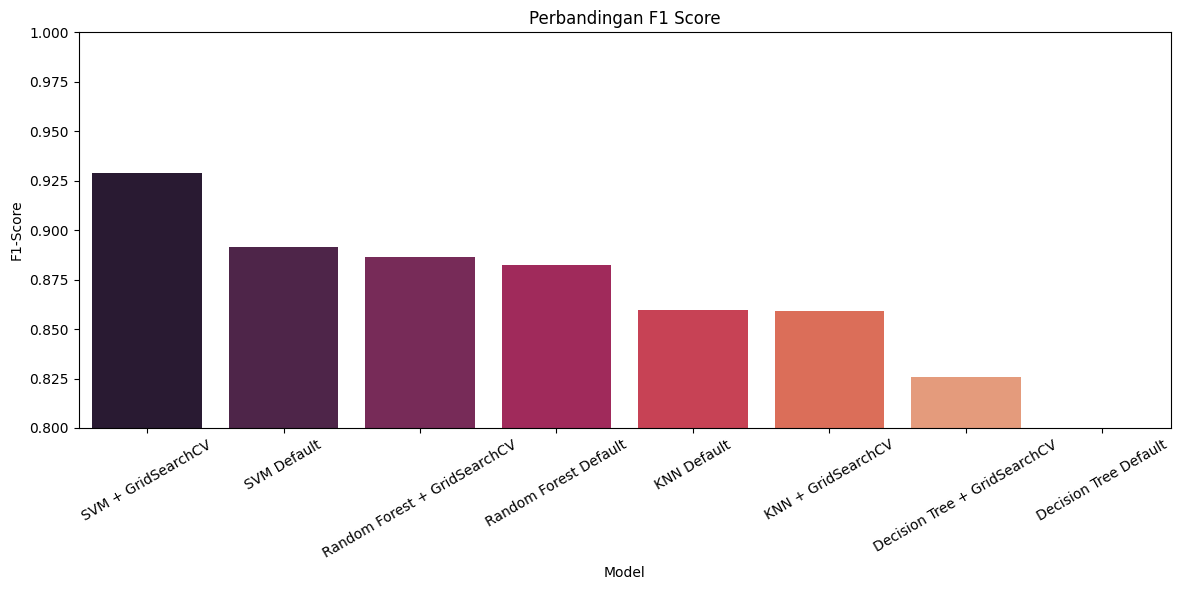

In [62]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=hasil_df,

    x="Model",

    y="F1-Score",

    palette="rocket"

)

plt.xticks(rotation=30)

plt.ylim(0.80,1.00)

plt.title("Perbandingan F1 Score")

plt.tight_layout()

plt.show()

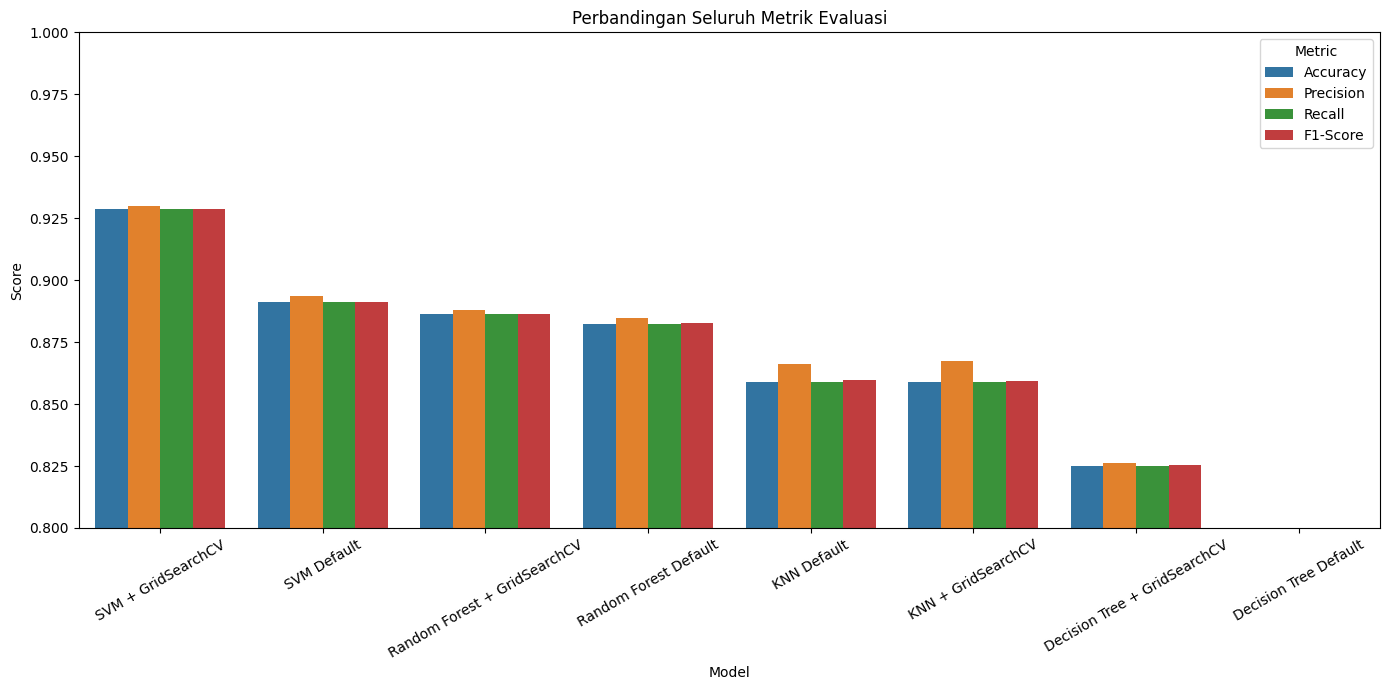

In [63]:
# ============================================================
# GRAFIK PERBANDINGAN SEMUA METRIK
# ============================================================

hasil_long = hasil_df.melt(

    id_vars="Model",

    value_vars=[

        "Accuracy",

        "Precision",

        "Recall",

        "F1-Score"

    ],

    var_name="Metric",

    value_name="Score"

)

plt.figure(figsize=(14,7))

sns.barplot(

    data=hasil_long,

    x="Model",

    y="Score",

    hue="Metric"

)

plt.xticks(rotation=30)

plt.ylim(0.80,1.00)

plt.title("Perbandingan Seluruh Metrik Evaluasi")

plt.tight_layout()

plt.show()

In [64]:
print("="*70)

print("RANKING MODEL")

print("="*70)

ranking = hasil_df.sort_values(

    by="Accuracy",

    ascending=False

)

ranking.insert(

    0,

    "Ranking",

    range(1,len(ranking)+1)

)

display(ranking)

RANKING MODEL


,Ranking,Model,Accuracy,Precision,Recall,F1-Score
0,1,SVM + GridSearchCV,0.92875,0.930097,0.92875,0.928747
1,2,SVM Default,0.89125,0.893678,0.89125,0.891293
2,3,Random Forest + GridSearchCV,0.88625,0.887889,0.88625,0.886226
3,4,Random Forest Default,0.88250,0.884660,0.88250,0.882514
4,5,KNN Default,0.85875,0.866121,0.85875,0.859621
5,6,KNN + GridSearchCV,0.85875,0.867258,0.85875,0.859374
6,7,Decision Tree + GridSearchCV,0.82500,0.826363,0.82500,0.825516
7,8,Decision Tree Default,0.77375,0.775975,0.77375,0.774206


In [65]:
ranking.to_excel(

    "ranking_model.xlsx",

    index=False

)

In [66]:
best_model = ranking.iloc[0]

print("="*70)

print("MODEL TERBAIK")

print("="*70)

print(f"Model      : {best_model['Model']}")

print(f"Accuracy   : {best_model['Accuracy']:.4f}")

print(f"Precision  : {best_model['Precision']:.4f}")

print(f"Recall     : {best_model['Recall']:.4f}")

print(f"F1 Score   : {best_model['F1-Score']:.4f}")

print("="*70)

MODEL TERBAIK
Model      : SVM + GridSearchCV
Accuracy   : 0.9287
Precision  : 0.9301
Recall     : 0.9287
F1 Score   : 0.9287


ini beda ya

In [67]:
import os
import cv2
import numpy as np
import pandas as pd

from skimage.feature import graycomatrix, graycoprops

# ==============================
# Folder Dataset
# ==============================
dataset_path = "/content/drive/MyDrive/pengolahan_cita_digital/archive/MangoLeafBD Dataset/"

# ==============================
# Menyimpan hasil ekstraksi
# ==============================
hasil = []

nomor = 1

# ==============================
# Membaca setiap folder kelas
# ==============================
for label in os.listdir(dataset_path):

    folder = os.path.join(dataset_path, label)

    if not os.path.isdir(folder):
        continue

    for file in os.listdir(folder):

        path = os.path.join(folder, file)

        # Membaca gambar
        img = cv2.imread(path)

        if img is None:
            continue

        # Konversi ke grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # ==============================
        # Membentuk GLCM
        # ==============================
        glcm = graycomatrix(
            gray,
            distances=[1],
            angles=[0],
            levels=256,
            symmetric=True,
            normed=True
        )

        # ==============================
        # Ekstraksi fitur
        # ==============================
        contrast = graycoprops(glcm, 'contrast')[0, 0]
        correlation = graycoprops(glcm, 'correlation')[0, 0]
        energy = graycoprops(glcm, 'energy')[0, 0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

        # ==============================
        # Menghitung Entropy
        # ==============================
        p = glcm[:, :, 0, 0]

        entropy = -np.sum(
            p * np.log2(p + 1e-10)
        )

        # ==============================
        # Simpan hasil
        # ==============================
        hasil.append([
            nomor,
            round(contrast, 4),
            round(correlation, 4),
            round(energy, 4),
            round(homogeneity, 4),
            round(entropy, 4),
            label
        ])

        nomor += 1

# ==============================
# Membuat DataFrame
# ==============================
df = pd.DataFrame(
    hasil,
    columns=[
        "No",
        "Contrast",
        "Correlation",
        "Energy",
        "Homogeneity",
        "Entropy",
        "Label"
    ]
)

# ==============================
# Menampilkan 10 data pertama
# ==============================
print(df.head(10))

# ==============================
# Simpan ke Excel
# ==============================
df.to_excel(
    "Hasil_Ekstraksi_GLCM.xlsx",
    index=False
)

# ==============================
# Simpan ke CSV
# ==============================
df.to_csv(
    "Hasil_Ekstraksi_GLCM.csv",
    index=False
)

print("\nEkstraksi selesai.")
print("File tersimpan sebagai:")
print("- Hasil_Ekstraksi_GLCM.xlsx")
print("- Hasil_Ekstraksi_GLCM.csv")

   No  Contrast  Correlation  Energy  Homogeneity  Entropy        Label
0   1   89.6188       0.9802  0.0260       0.2886  11.6247  Sooty Mould
1   2   73.2494       0.9847  0.0426       0.3466  10.8310  Sooty Mould
2   3   30.3061       0.9923  0.0495       0.3898  10.3327  Sooty Mould
3   4   36.1296       0.9945  0.0351       0.4014  10.7889  Sooty Mould
4   5   75.0510       0.9846  0.0508       0.3774  10.4209  Sooty Mould
5   6   48.7219       0.9925  0.0345       0.3933  11.0551  Sooty Mould
6   7   58.8417       0.9887  0.0282       0.3175  11.4086  Sooty Mould
7   8   75.0981       0.9898  0.0290       0.3088  11.6796  Sooty Mould
8   9   71.3800       0.9870  0.0336       0.3491  11.2954  Sooty Mould
9  10   79.3022       0.9859  0.0449       0.3592  10.7744  Sooty Mould

Ekstraksi selesai.
File tersimpan sebagai:
- Hasil_Ekstraksi_GLCM.xlsx
- Hasil_Ekstraksi_GLCM.csv


test optimasi


In [71]:
import pandas as pd

# ==========================
# Membaca dataset
# ==========================

csv_path = "/content/drive/MyDrive/pengolahan_cita_digital/archive/MangoLeafBD Dataset/glcm_features_v3.csv"

df = pd.read_csv(csv_path)

# ==========================
# Menghitung rata-rata setiap fitur GLCM
# ==========================

contrast_cols = [c for c in df.columns if c.startswith("Contrast")]

correlation_cols = [c for c in df.columns if c.startswith("Correlation")]

energy_cols = [c for c in df.columns if c.startswith("Energy")]

homogeneity_cols = [c for c in df.columns if c.startswith("Homogeneity")]

df["Contrast"] = df[contrast_cols].mean(axis=1)

df["Correlation"] = df[correlation_cols].mean(axis=1)

df["Energy"] = df[energy_cols].mean(axis=1)

df["Homogeneity"] = df[homogeneity_cols].mean(axis=1)

# ==========================
# Membuat tabel rata-rata tiap kelas
# ==========================

tabel2 = (
    df.groupby("Label")[
        [
            "Contrast",
            "Correlation",
            "Energy",
            "Homogeneity",
            "Entropy"
        ]
    ]
    .mean()
    .round(4)
    .reset_index()
)

# ==========================
# Urutan kelas
# ==========================

urutan = [
    "Anthracnose",
    "Bacterial Canker",
    "Cutting Weevil",
    "Die Back",
    "Gall Midge",
    "Healthy",
    "Powdery Mildew",
    "Sooty Mould"
]

tabel2["Label"] = pd.Categorical(
    tabel2["Label"],
    categories=urutan,
    ordered=True
)

tabel2 = tabel2.sort_values("Label")

# Tambah nomor
tabel2.insert(0, "No", range(1, len(tabel2) + 1))

# Tampilkan
display(tabel2)

# Simpan ke Excel
tabel2.to_excel(
    "Tabel_2_Hasil_Ekstraksi_GLCM.xlsx",
    index=False
)

print("Tabel berhasil disimpan.")

,No,Label,Contrast,Correlation,Energy,Homogeneity,Entropy
0,1,Anthracnose,87.0713,0.9748,0.0655,0.4939,6.5164
1,2,Bacterial Canker,117.9911,0.9549,0.0491,0.3459,6.3943
2,3,Cutting Weevil,245.4005,0.9153,0.0607,0.5097,6.5390
3,4,Die Back,78.3914,0.9765,0.0595,0.4884,6.5842
4,5,Gall Midge,114.6439,0.9806,0.0766,0.4985,6.4659
5,6,Healthy,133.2874,0.9815,0.0724,0.5103,6.5174
6,7,Powdery Mildew,167.3758,0.9775,0.0570,0.4176,7.0729
7,8,Sooty Mould,173.6875,0.9691,0.0404,0.3433,7.1142


Tabel berhasil disimpan.


In [72]:
import pandas as pd

# ==========================================
# TABEL 3
# Hyperparameter Terbaik Hasil GridSearchCV
# ==========================================

tabel3 = pd.DataFrame({
    "Algoritma": [
        "SVM",
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],
    "Hyperparameter Terbaik": [
        str(grid_svm.best_params_),
        str(grid_knn.best_params_),
        str(grid_dt.best_params_),
        str(grid_rf.best_params_)
    ]
})

display(tabel3)

tabel3.to_excel(
    "Tabel_3_Hyperparameter_Terbaik.xlsx",
    index=False
)

print("Tabel 3 berhasil disimpan.")

,Algoritma,Hyperparameter Terbaik
0,SVM,"{'model__C': 10, 'model__gamma': 'scale', 'mod..."
1,KNN,"{'model__n_neighbors': 3, 'model__weights': 'd..."
2,Decision Tree,"{'criterion': 'entropy', 'max_depth': 20, 'min..."
3,Random Forest,"{'criterion': 'gini', 'max_depth': None, 'max_..."


Tabel 3 berhasil disimpan.
